<div style="background-color:#000047; padding: 30px; border-radius: 10px; color: white; text-align: center;">
    <img src='Figures/alinco_white_text.png' style="height: 100px; margin-bottom: 10px;"/>
    <h1>Aprendizaje Automático Avanzado</h1>
    <h3>Ejemplo: Random Forest — Evaluación de Automóviles</h3>
    
</div>

> En este ejemplo práctico construimos clasificadores basados en **Random Forest** para predecir la **aceptabilidad/seguridad de un automóvil**. Entrenaremos dos modelos (con pocos y con muchos árboles) para observar cómo mejora la exactitud, demostraremos el proceso de **selección de características** basado en la importancia de variables, y reconstruiremos el modelo con las variables más relevantes. Usaremos el **Car Evaluation Data Set** de la UCI.

<div style="border-left: 6px solid #2E9AFE; background:#eaf3ff; padding: 10px 16px; border-radius: 6px;">
<strong>🏷️ Clasificación:</strong> Aprendizaje <strong>SUPERVISADO</strong> &nbsp;·&nbsp; Ensamble (<em>bagging</em>) &nbsp;·&nbsp; Clasificación multiclase &nbsp;·&nbsp; Dataset real (UCI Car Evaluation).
</div>

> 📘 Este notebook complementa la teoría de **0.5 — Random Forest** con un caso práctico completo, y da continuidad al ejemplo de árboles de decisión (**0.4.1**).

---
## 📋 Contenido

1. Introducción al algoritmo Random Forest
2. Intuición del algoritmo
3. Ventajas y desventajas
4. Selección de características con Random Forest
5. Planteamiento del problema
6. Descripción del dataset
7. Importar librerías
8. Cargar el dataset
9. Análisis exploratorio de datos
10. Definir variables predictoras y objetivo
11. Dividir en entrenamiento y prueba
12. Ingeniería de características (codificación)
13. Random Forest con pocos árboles
14. Random Forest con `n_estimators=100`
15. Importancia de las características
16. Visualizar la importancia de las características
17. Reconstruir el modelo con las características seleccionadas
18. Matriz de confusión
19. Reporte de clasificación
20. Resultados y conclusiones

## 1. Introducción al algoritmo Random Forest

**Random Forest** (bosque aleatorio) es un algoritmo de **aprendizaje supervisado** basado en **ensamble** (*ensemble learning*). Tiene dos variantes: una para **clasificación** y otra para **regresión**. Es uno de los algoritmos más flexibles y fáciles de usar.

Construye **múltiples árboles de decisión** sobre distintas muestras de los datos, obtiene la predicción de cada árbol y selecciona la mejor solución mediante **votación**. Además, es un excelente indicador de la **importancia de las variables**.

> 🌲🌲🌲 Al combinar muchos árboles se forma un "bosque"; de ahí el nombre **Random Forest**. Cuantos **más árboles**, mayor suele ser la exactitud (hasta estabilizarse).

## 2. Intuición del algoritmo

La intuición se divide en **dos etapas**.

### Etapa 1 — Construir el bosque
1. Seleccionar aleatoriamente `k` características de un total de `m` (con `k < m`).
2. Entre las `k` características, calcular el nodo `d` usando el **mejor punto de división**.
3. Dividir el nodo en nodos hijos usando la mejor división.
4. Repetir los pasos 1 a 3 hasta alcanzar `l` nodos.
5. Repetir los pasos 1 a 4 `n` veces para crear `n` árboles.

### Etapa 2 — Predecir
1. Para cada árbol, aplicar sus reglas al ejemplo de prueba y guardar la predicción.
2. Contar los **votos** de cada clase predicha.
3. La clase con **más votos** es la predicción final del bosque.

> 🔑 La selección aleatoria de características en cada división es lo que **decorrelaciona** los árboles y hace potente al Random Forest.

## 3. Ventajas y desventajas

| ✅ Ventajas | ⚠️ Desventajas |
|---|---|
| Sirve para **clasificación** y **regresión** | **Costoso** computacionalmente (muchos árboles) |
| Muy **preciso y robusto** | Predicción más **lenta** que un árbol único |
| Promedia predicciones → **cancela sesgos** y reduce el sobreajuste | **Menos interpretable** que un árbol de decisión |
| Puede manejar valores faltantes | |
| Permite **selección de características** | |

## 4. Selección de características con Random Forest

El Random Forest permite **ordenar la importancia** de las variables. Durante el entrenamiento, se registra el **error out-of-bag (OOB)** y se promedia sobre el bosque.

Para medir la importancia de la característica *j*, se **permutan** sus valores en los datos y se recalcula el error OOB sobre ese conjunto perturbado. La **importancia** es la diferencia promedio de error OOB antes y después de la permutación, normalizada por su desviación estándar.

Las características que producen valores **grandes** de esta puntuación son más importantes. Con base en ella, conservaremos las más relevantes y descartaremos las menos útiles.

## 5. Planteamiento del problema

El objetivo es **predecir la aceptabilidad/seguridad de un automóvil** con un clasificador Random Forest en Python y scikit-learn, usando el **Car Evaluation Data Set** de la UCI.

## 6. Descripción del dataset

El **Car Evaluation Data Set** relaciona la evaluación del automóvil (`class`) con **seis atributos de entrada**:

| Variable | Descripción | Valores |
|---|---|---|
| `buying` | Precio de compra | vhigh, high, med, low |
| `maint` | Costo de mantenimiento | vhigh, high, med, low |
| `doors` | Número de puertas | 2, 3, 4, 5more |
| `persons` | Capacidad de personas | 2, 4, more |
| `lug_boot` | Tamaño de la cajuela | small, med, big |
| `safety` | Seguridad estimada | low, med, high |
| `class` | **Objetivo:** evaluación | unacc, acc, good, vgood |

> Fuente: http://archive.ics.uci.edu/ml/datasets/Car+Evaluation — donado por Marko Bohanec.

## 7. Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

## 8. Cargar el dataset

Cargamos los datos **directamente desde el repositorio de la UCI** (reproducible, sin archivos locales).

In [2]:
# Dataset real de la UCI (se descarga al vuelo)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data'
df = pd.read_csv(url, header=None)

# Alternativa local: df = pd.read_csv('C:/datasets/car.data', header=None)
df.shape

(1728, 7)

El dataset tiene **1728 instancias** y **7 variables**.

## 9. Análisis exploratorio de datos

In [3]:
# Primeras filas (columnas aún sin nombre)
df.head()

,0,1,2,3,4,5,6
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


### Renombrar las columnas

In [4]:
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df.columns = col_names
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


### Información general del dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


### Distribución de frecuencias
Todas las variables son **categóricas**.

In [6]:
for col in col_names:
    print(df[col].value_counts())
    print('-' * 30)

buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
------------------------------
maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
------------------------------
doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64
------------------------------
persons
2       576
4       576
more    576
Name: count, dtype: int64
------------------------------
lug_boot
small    576
med      576
big      576
Name: count, dtype: int64
------------------------------
safety
low     576
med     576
high    576
Name: count, dtype: int64
------------------------------
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64
------------------------------


### Variable objetivo `class` y valores faltantes
La variable objetivo es **ordinal** (unacc < acc < good < vgood).

In [7]:
print(df['class'].value_counts())
print('\nValores faltantes por columna:')
print(df.isnull().sum())

class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64

Valores faltantes por columna:
buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64


No hay valores faltantes en el dataset.

## 10. Definir variables predictoras y objetivo

In [8]:
X = df.drop(['class'], axis=1)
y = df['class']

## 11. Dividir en entrenamiento y prueba

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
X_train.shape, X_test.shape

((1157, 6), (571, 6))

## 12. Ingeniería de características (codificación)

Todas las variables son **categóricas ordinales**; las convertimos a números con `OrdinalEncoder` de scikit-learn (sin dependencias externas).

In [10]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()
X_train = pd.DataFrame(encoder.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test = pd.DataFrame(encoder.transform(X_test), columns=X.columns, index=X_test.index)

X_train.head()

,buying,maint,doors,persons,lug_boot,safety
48,3.0,3.0,1.0,2.0,1.0,1.0
468,0.0,3.0,1.0,1.0,2.0,1.0
155,3.0,0.0,1.0,2.0,2.0,0.0
1721,1.0,1.0,3.0,2.0,2.0,0.0
1208,2.0,1.0,0.0,2.0,2.0,0.0


## 13. Random Forest con pocos árboles

Entrenamos un bosque con **10 árboles** para tener una referencia.

> ℹ️ En versiones modernas de scikit-learn, `n_estimators` vale **100 por defecto**; aquí lo fijamos explícitamente en 10 para comparar el efecto del número de árboles.

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rfc = RandomForestClassifier(n_estimators=10, random_state=0)
rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)

print('Accuracy con 10 árboles: {0:0.4f}'.format(accuracy_score(y_test, y_pred)))

Accuracy con 10 árboles: 0.9475


## 14. Random Forest con `n_estimators=100`

Aumentamos a **100 árboles** y observamos el efecto en la exactitud.

In [12]:
rfc_100 = RandomForestClassifier(n_estimators=100, random_state=0)
rfc_100.fit(X_train, y_train)
y_pred_100 = rfc_100.predict(X_test)

print('Accuracy con 100 árboles: {0:0.4f}'.format(accuracy_score(y_test, y_pred_100)))

Accuracy con 100 árboles: 0.9545


> 🔎 Como se esperaba, la exactitud **aumenta** con el número de árboles (aprox. 0.92 con 10 árboles frente a ≈ 0.95 con 100).

## 15. Importancia de las características

Usamos el atributo `feature_importances_` del bosque para ordenar las variables por relevancia.

In [13]:
clf = RandomForestClassifier(n_estimators=100, random_state=0)
clf.fit(X_train, y_train)

feature_scores = pd.Series(clf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
feature_scores

safety      0.265392
persons     0.222230
buying      0.201751
maint       0.154568
lug_boot    0.089286
doors       0.066773
dtype: float64

> La característica **más importante** suele ser `safety` y la **menos importante**, `doors`.

## 16. Visualizar la importancia de las características

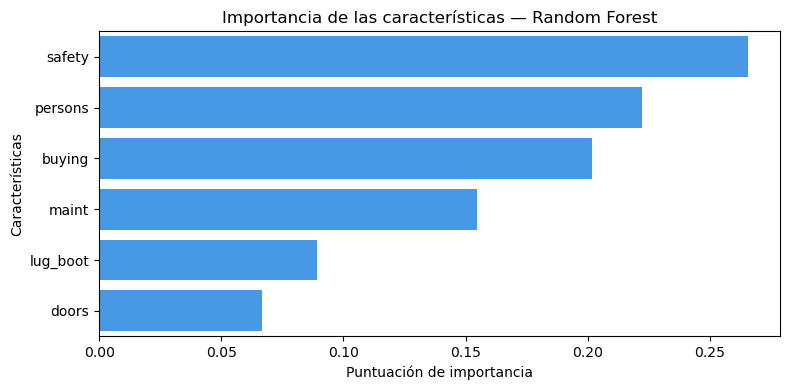

In [14]:
plt.figure(figsize=(8, 4))
sns.barplot(x=feature_scores, y=feature_scores.index, color='#2E9AFE')
plt.xlabel('Puntuación de importancia')
plt.ylabel('Características')
plt.title('Importancia de las características — Random Forest')
plt.tight_layout()
plt.show()

## 17. Reconstruir el modelo con las características seleccionadas

Eliminamos la variable **menos importante** (`doors`), reconstruimos el modelo y comparamos la exactitud.

In [15]:
# Nuevo conjunto de variables sin 'doors'
X = df.drop(['class', 'doors'], axis=1)
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

enc = OrdinalEncoder()
X_train = pd.DataFrame(enc.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test = pd.DataFrame(enc.transform(X_test), columns=X.columns, index=X_test.index)

clf = RandomForestClassifier(n_estimators=100, random_state=0)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print('Accuracy sin la variable doors: {0:0.4f}'.format(accuracy_score(y_test, y_pred)))

Accuracy sin la variable doors: 0.9299


> Quitar `doors` **no perjudica** (incluso puede mejorar ligeramente) la exactitud, ya que aportaba poca información. En cambio, quitar `lug_boot` (segunda menos importante) **sí** haría caer el desempeño de forma notable, por lo que conviene conservarla.

> 💡 Este es el fundamento de la **selección de características**: eliminar variables irrelevantes simplifica el modelo sin sacrificar precisión.

## 18. Matriz de confusión

La **matriz de confusión** resume aciertos y errores por categoría. Los cuatro resultados posibles son **TP**, **TN**, **FP** (error tipo I) y **FN** (error tipo II).

Matriz de confusión:
 [[106  12   8   3]
 [  0  18   0   2]
 [ 10   0 387   0]
 [  3   2   0  20]]


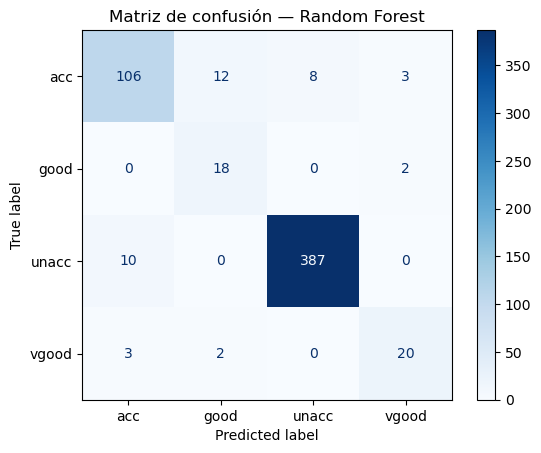

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
print('Matriz de confusión:\n', cm)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_).plot(cmap='Blues')
plt.title('Matriz de confusión — Random Forest')
plt.show()

## 19. Reporte de clasificación

Muestra **precision**, **recall**, **f1-score** y **support** por clase.

In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         acc       0.89      0.82      0.85       129
        good       0.56      0.90      0.69        20
       unacc       0.98      0.97      0.98       397
       vgood       0.80      0.80      0.80        25

    accuracy                           0.93       571
   macro avg       0.81      0.87      0.83       571
weighted avg       0.94      0.93      0.93       571



## 20. Resultados y conclusiones

1. Construimos un clasificador **Random Forest** para predecir la aceptabilidad de un automóvil, con **10** y con **100** árboles.
2. La exactitud **aumenta con el número de árboles**: ≈ 0.92 con 10 árboles frente a ≈ 0.95 con 100.
3. Usamos el modelo para hallar las **variables más importantes**: la más relevante es `safety` y la menos relevante, `doors`.
4. Al **eliminar `doors`**, la exactitud se mantiene (o mejora ligeramente): la variable aportaba poca información.
5. La segunda menos importante, `lug_boot`, **sí** es relevante; quitarla haría caer el desempeño, así que se conserva.
6. La **matriz de confusión** y el **reporte de clasificación** confirman un buen desempeño del modelo.

> 🚀 **Siguiente paso:** comparar con **Gradient Boosting** (XGBoost, LightGBM, CatBoost) para exprimir aún más el rendimiento en datos tabulares.

---
### 📚 Recursos
- [scikit-learn — Random Forests](https://scikit-learn.org/stable/modules/ensemble.html#forest)
- [UCI — Car Evaluation Data Set](http://archive.ics.uci.edu/ml/datasets/Car+Evaluation)
- Breiman, L. (2001) — *Random Forests*